# House Price Prediction India

In [90]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import kagglehub


## Load Dataset into memory

In [91]:
path = kagglehub.dataset_download("mohamedafsal007/house-price-dataset-of-india")

print("Path to dataset files:", path)

Path to dataset files: /Users/mac/.cache/kagglehub/datasets/mohamedafsal007/house-price-dataset-of-india/versions/1


In [92]:
import os

print(os.listdir(path))

['House Price India.csv']


In [93]:
file_path = os.path.join(
    path,
    "House Price India.csv"
)

df = pd.read_csv(file_path)

## Exploratory Data Analysis

In [94]:
df.head()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,6762810145,42491,5,2.50,3650,9050,2.0,0,4,5,...,1921,0,122003,52.8645,-114.557,2880,5400,2,58,2380000
1,6762810635,42491,4,2.50,2920,4000,1.5,0,0,5,...,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1400000
2,6762810998,42491,5,2.75,2910,9480,1.5,0,0,3,...,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1200000
3,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000
4,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,...,1929,0,122006,52.9047,-114.485,2060,4500,1,51,805000


In [95]:
df.columns

Index(['id', 'Date', 'number of bedrooms', 'number of bathrooms',
       'living area', 'lot area', 'number of floors', 'waterfront present',
       'number of views', 'condition of the house', 'grade of the house',
       'Area of the house(excluding basement)', 'Area of the basement',
       'Built Year', 'Renovation Year', 'Postal Code', 'Lattitude',
       'Longitude', 'living_area_renov', 'lot_area_renov',
       'Number of schools nearby', 'Distance from the airport', 'Price'],
      dtype='object')

In [96]:
df.dtypes

id                                         int64
Date                                       int64
number of bedrooms                         int64
number of bathrooms                      float64
living area                                int64
lot area                                   int64
number of floors                         float64
waterfront present                         int64
number of views                            int64
condition of the house                     int64
grade of the house                         int64
Area of the house(excluding basement)      int64
Area of the basement                       int64
Built Year                                 int64
Renovation Year                            int64
Postal Code                                int64
Lattitude                                float64
Longitude                                float64
living_area_renov                          int64
lot_area_renov                             int64
Number of schools ne

In [97]:
df.drop("id", axis=1, inplace=True)

In [98]:
df["Date"].describe()

count    14620.000000
mean     42604.538646
std         67.347991
min      42491.000000
25%      42546.000000
50%      42600.000000
75%      42662.000000
max      42734.000000
Name: Date, dtype: float64

In [99]:
df["Price"].describe()

count    1.462000e+04
mean     5.389322e+05
std      3.675324e+05
min      7.800000e+04
25%      3.200000e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: Price, dtype: float64

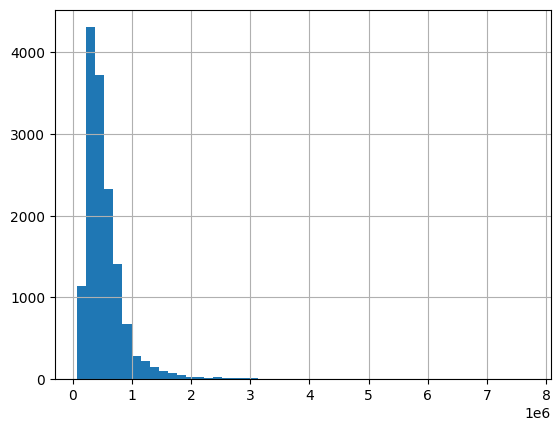

In [100]:
df["Price"].hist(bins=50)
plt.show()

## Feature Engineering

In [101]:
df["Date"] = pd.to_datetime(df["Date"],  origin="1899-12-30",
    unit="D")

In [102]:
df["Date"].head()

0   2016-05-01
1   2016-05-01
2   2016-05-01
3   2016-05-01
4   2016-05-01
Name: Date, dtype: datetime64[ns]

In [103]:
df["sale_year"] = df["Date"].dt.year
df["sale_month"] = df["Date"].dt.month

In [104]:
df.head()

,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,grade of the house,...,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price,sale_year,sale_month
0,2016-05-01,5,2.50,3650,9050,2.0,0,4,5,10,...,122003,52.8645,-114.557,2880,5400,2,58,2380000,2016,5
1,2016-05-01,4,2.50,2920,4000,1.5,0,0,5,8,...,122004,52.8878,-114.470,2470,4000,2,51,1400000,2016,5
2,2016-05-01,5,2.75,2910,9480,1.5,0,0,3,8,...,122004,52.8852,-114.468,2940,6600,1,53,1200000,2016,5
3,2016-05-01,4,2.50,3310,42998,2.0,0,0,3,9,...,122005,52.9532,-114.321,3350,42847,3,76,838000,2016,5
4,2016-05-01,3,2.00,2710,4500,1.5,0,0,4,8,...,122006,52.9047,-114.485,2060,4500,1,51,805000,2016,5


In [105]:
df.drop("Date", axis=1, inplace=True)

In [106]:
df.head()

,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,grade of the house,Area of the house(excluding basement),...,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price,sale_year,sale_month
0,5,2.50,3650,9050,2.0,0,4,5,10,3370,...,122003,52.8645,-114.557,2880,5400,2,58,2380000,2016,5
1,4,2.50,2920,4000,1.5,0,0,5,8,1910,...,122004,52.8878,-114.470,2470,4000,2,51,1400000,2016,5
2,5,2.75,2910,9480,1.5,0,0,3,8,2910,...,122004,52.8852,-114.468,2940,6600,1,53,1200000,2016,5
3,4,2.50,3310,42998,2.0,0,0,3,9,3310,...,122005,52.9532,-114.321,3350,42847,3,76,838000,2016,5
4,3,2.00,2710,4500,1.5,0,0,4,8,1880,...,122006,52.9047,-114.485,2060,4500,1,51,805000,2016,5


In [107]:
df['house_age'] = df['sale_year'] - df["Built Year"]

In [108]:
df['house_age'].head()

0     95
1    107
2     77
3     15
4     87
Name: house_age, dtype: int64

In [ ]:
df['years_since_renovation'] = (df['sale_year'] - df['Renovation Year'])

In [111]:
df["basement_ratio"] = (
    df["Area of the basement"] /
    df["living area"]
)

## Train/Test Split

In [113]:
from sklearn.model_selection import train_test_split

X = df.drop("Price", axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Training

#### Linear Regression Model Training

In [114]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


##### Evaluating the Linear Regression Model above

In [115]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

predictions = model.predict(X_test)

print("Mean Absolute Error : ", mean_absolute_error(y_test, predictions))
print("Mean Squared Error : ", mean_squared_error(y_test, predictions))
print("R2 : ", r2_score(y_test, predictions))

Mean Absolute Error :  123951.45949153938
Mean Squared Error :  38563425213.42117
R2 :  0.7263432269192918


#### XGBoost Model Training

In [127]:
from xgboost import XGBRegressor

xgModel = XGBRegressor(
    n_estimator=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    random_state=42
)
xgModel.fit(X_train, y_train)

[22:32:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimator" } are not used.



,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [128]:
xgPredictions = xgModel.predict(X_test)

##### Evaluating the XGBoost Model above

In [129]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(y_test, xgPredictions)
rmse = np.sqrt(mean_squared_error(y_test, xgPredictions))
r2 = r2_score(y_test, xgPredictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 69936.1015625
RMSE: 129795.07688660614
R² Score: 0.8804507255554199
